# Task 2: Conditional WGAN-GP on CelebA
**CSIT 595 Special Topics for GenAI — Assignment 2**

This notebook implements a **Conditional** Wasserstein GAN with Gradient Penalty (cWGAN-GP) trained on CelebA.

**Assigned attribute**: Replace `ATTRIBUTE` below with your assigned one:
- A–H → `Smiling`
- I–Q → `Blond_Hair`
- R–Z → `Eyeglasses`

Conditioning strategy:
- **Generator**: label is embedded → concatenated with z before the first layer
- **Critic**: label is embedded → projected to a spatial map → concatenated as an extra channel to the image

## 1. Imports & Configuration

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
from PIL import Image

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ─────────────────────────────────────────────────────────────────────────────
# !! CHANGE THIS to your assigned attribute !!
# Options: 'Smiling'  |  'Blond_Hair'  |  'Eyeglasses'
ATTRIBUTE = 'Blond_Hair'
# ─────────────────────────────────────────────────────────────────────────────

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = 64
CHANNELS    = 3
LATENT_DIM  = 128
EMBED_DIM   = 64        # Dimension of label embedding vector
N_CLASSES   = 2         # Binary attribute: 0 or 1
BATCH_SIZE  = 256
LR          = 1e-4
BETAS       = (0.0, 0.9)
N_CRITIC    = 5
LAMBDA_GP   = 10
NUM_EPOCHS  = 50        # Reduce if compute is limited
FEATURES_G  = 64
FEATURES_C  = 64

# ── Paths ────────────────────────────────────────────────────────────────────
IMAGE_DIR  = 'img_align_celeba/img_align_celeba'
ATTR_CSV   = 'list_attr_celeba.csv'

print(f'Conditioning on attribute: [{ATTRIBUTE}]')

Using device: cuda
Conditioning on attribute: [Blond_Hair]


## 2. Dataset with Attribute Labels

Attribute [Blond_Hair]: 29983 positive (label=1), 172616 negative (label=0)

Dataset size : 202,599 images
Batches/epoch: 791


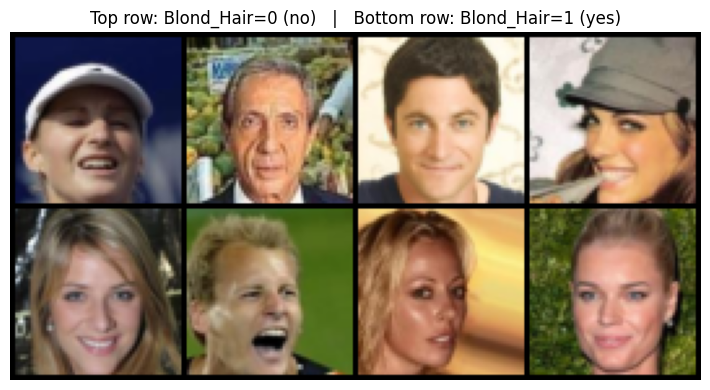

In [2]:
class CelebAConditionalDataset(Dataset):
    """
    CelebA dataset that returns (image, label) pairs.

    - Loads the attribute CSV to extract the target binary label.
    - Converts CelebA's {-1, +1} encoding to {0, 1}.
    - Applies standard resize → center-crop → normalize preprocessing.

    Args:
        image_dir   : Path to folder containing .jpg images
        attr_csv    : Path to list_attr_celeba.csv
        attribute   : Column name of the target attribute (e.g. 'Smiling')
        max_samples : Optional cap on dataset size for compute efficiency
    """

    def __init__(self, image_dir, attr_csv, attribute, max_samples=None):
        self.image_dir = image_dir

        # Load attributes; first column is image filename
        df = pd.read_csv(attr_csv)
        if max_samples is not None:
            df = df.iloc[:max_samples]

        # Validate attribute name
        if attribute not in df.columns:
            raise ValueError(f"Attribute '{attribute}' not found. "
                             f"Available: {list(df.columns)}")

        self.filenames = df.iloc[:, 0].tolist()         # image filenames

        # Convert {-1, +1}  →  {0, 1}
        raw_labels = df[attribute].values               # array of -1 / +1
        self.labels = ((raw_labels + 1) // 2).astype(np.int64)  # 0 or 1

        # Check class balance
        pos = self.labels.sum()
        neg = len(self.labels) - pos
        print(f'Attribute [{attribute}]: {pos} positive (label=1), {neg} negative (label=0)')

        self.transform = transforms.Compose([
            transforms.Resize(72),
            transforms.CenterCrop(IMG_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        path  = os.path.join(self.image_dir, self.filenames[idx])
        img   = Image.open(path).convert('RGB')
        label = self.labels[idx]                        # int scalar
        return self.transform(img), torch.tensor(label, dtype=torch.long)


# ── Build DataLoader ──────────────────────────────────────────────────────────
# Set max_samples=50000 if compute is tight
dataset    = CelebAConditionalDataset(IMAGE_DIR, ATTR_CSV, ATTRIBUTE, max_samples=None)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
)

print(f'\nDataset size : {len(dataset):,} images')
print(f'Batches/epoch: {len(dataloader):,}')

# ── Sanity check: show real samples per class ─────────────────────────────────
imgs, labels = next(iter(dataloader))
idx0 = (labels == 0).nonzero(as_tuple=True)[0][:4]
idx1 = (labels == 1).nonzero(as_tuple=True)[0][:4]
sample = torch.cat([imgs[idx0], imgs[idx1]], dim=0)

grid = make_grid(sample, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title(f'Top row: {ATTRIBUTE}=0 (no)   |   Bottom row: {ATTRIBUTE}=1 (yes)')
plt.tight_layout()
plt.show()

## 3. Architecture

### Conditioning Strategy

#### Generator
The condition label `y ∈ {0, 1}` is passed through an `nn.Embedding(2, EMBED_DIM)` layer to produce a dense embedding vector **e ∈ ℝ⁶⁴**. This is concatenated with the latent vector **z ∈ ℝ¹²⁸** to form the input **[z ∥ e] ∈ ℝ¹⁹²**, which is then fed into the first transposed convolution. This way, every feature map produced by the generator is conditioned on the label from the very beginning.

#### Critic
For the critic, the label embedding is projected to a **spatial map of size IMG_SIZE × IMG_SIZE** using a linear layer, then reshaped and concatenated as an extra channel to the input image. This gives the critic a `(3+1) × 64 × 64` input — the image channels plus a "label channel" — making it aware of the condition at every spatial location.

In [3]:
def weights_init(module):
    """DCGAN-style weight initialisation."""
    classname = module.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0.0)


# ─────────────────────────────────────────────────────────────────────────────
# Conditional Generator
# ─────────────────────────────────────────────────────────────────────────────
class ConditionalGenerator(nn.Module):
    """
    Conditional DCGAN-style generator.

    Conditioning:
        label y  →  Embedding(n_classes, embed_dim)  →  e ∈ ℝ^embed_dim
        input    =  [z ∥ e]  ∈  ℝ^(latent_dim + embed_dim)

    This concatenation is performed before the very first layer, so
    condition information flows through the entire network.

    Input : z (N, latent_dim) + y (N,)
    Output: image (N, 3, 64, 64) in [-1, 1]
    """

    def __init__(self, latent_dim=LATENT_DIM, embed_dim=EMBED_DIM,
                 n_classes=N_CLASSES, features=FEATURES_G):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, embed_dim)

        # First layer input size = latent_dim + embed_dim
        in_dim = latent_dim + embed_dim

        self.net = nn.Sequential(
            # in_dim × 1 × 1  →  features*16 × 4 × 4
            self._block(in_dim,        features * 16, 4, 1, 0),
            # features*16 × 4 × 4  →  features*8 × 8 × 8
            self._block(features * 16, features * 8,  4, 2, 1),
            # features*8 × 8 × 8  →  features*4 × 16 × 16
            self._block(features * 8,  features * 4,  4, 2, 1),
            # features*4 × 16 × 16  →  features*2 × 32 × 32
            self._block(features * 4,  features * 2,  4, 2, 1),
            # features*2 × 32 × 32  →  3 × 64 × 64
            nn.ConvTranspose2d(features * 2, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    @staticmethod
    def _block(in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, z, y):
        """
        Args:
            z : (N, latent_dim)  — noise vector
            y : (N,)             — integer class labels {0, 1}
        Returns:
            img : (N, 3, 64, 64)
        """
        e     = self.label_emb(y)                  # (N, embed_dim)
        z_cond = torch.cat([z, e], dim=1)          # (N, latent_dim + embed_dim)
        # Reshape to (N, latent_dim+embed_dim, 1, 1) for ConvTranspose2d
        return self.net(z_cond.unsqueeze(-1).unsqueeze(-1))


# ─────────────────────────────────────────────────────────────────────────────
# Conditional Critic
# ─────────────────────────────────────────────────────────────────────────────
class ConditionalCritic(nn.Module):
    """
    Conditional DCGAN-style critic (no Sigmoid).

    Conditioning:
        label y  →  Embedding(n_classes, embed_dim)
                 →  Linear(embed_dim, IMG_SIZE * IMG_SIZE)
                 →  reshape to (N, 1, IMG_SIZE, IMG_SIZE)
        input    =  [image ∥ label_map]  with shape (N, 4, 64, 64)

    Concatenating as a spatial channel lets the critic examine the label
    at every spatial location of the image, which is more expressive than
    injecting only at the bottleneck.

    Input : image (N, 3, 64, 64) + y (N,)
    Output: scalar score (N, 1)  — no Sigmoid
    """

    def __init__(self, embed_dim=EMBED_DIM, n_classes=N_CLASSES,
                 img_size=IMG_SIZE, features=FEATURES_C):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_classes, embed_dim)
        # Project embedding to a full spatial map
        self.label_proj = nn.Linear(embed_dim, img_size * img_size)

        # Input channels = 3 (image) + 1 (label map)
        in_ch = CHANNELS + 1

        self.net = nn.Sequential(
            # 4 × 64 × 64  →  features × 32 × 32
            self._block(in_ch,         features,     4, 2, 1, norm=False),
            # features × 32 × 32  →  features*2 × 16 × 16
            self._block(features,      features * 2, 4, 2, 1),
            # features*2 × 16 × 16  →  features*4 × 8 × 8
            self._block(features * 2,  features * 4, 4, 2, 1),
            # features*4 × 8 × 8  →  features*8 × 4 × 4
            self._block(features * 4,  features * 8, 4, 2, 1),
            # features*8 × 4 × 4  →  1 × 1 × 1
            nn.Conv2d(features * 8, 1, 4, 1, 0, bias=False),
            # No Sigmoid — raw Wasserstein score
        )

    @staticmethod
    def _block(in_ch, out_ch, kernel, stride, padding, norm=True):
        layers = [nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=not norm)]
        if norm:
            # InstanceNorm is safe for gradient penalty (per-sample, not per-batch)
            layers.append(nn.InstanceNorm2d(out_ch, affine=True))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, img, y):
        """
        Args:
            img : (N, 3, 64, 64)
            y   : (N,)  integer class labels {0, 1}
        Returns:
            score : (N, 1)
        """
        e         = self.label_emb(y)                          # (N, embed_dim)
        label_map = self.label_proj(e)                         # (N, H*W)
        label_map = label_map.view(-1, 1, self.img_size, self.img_size)  # (N,1,H,W)
        x = torch.cat([img, label_map], dim=1)                 # (N, 4, H, W)
        return self.net(x).view(img.size(0), -1)               # (N, 1)


# ── Instantiate ───────────────────────────────────────────────────────────────
G = ConditionalGenerator().to(DEVICE)
C = ConditionalCritic().to(DEVICE)
G.apply(weights_init)
C.apply(weights_init)

n_G = sum(p.numel() for p in G.parameters() if p.requires_grad)
n_C = sum(p.numel() for p in C.parameters() if p.requires_grad)
print(f'Generator params : {n_G:,}')
print(f'Critic params    : {n_C:,}')

Generator params : 14,165,888
Critic params    : 3,033,024


## 4. Gradient Penalty (Conditional)

In [4]:
def compute_gradient_penalty(critic, real, fake, labels, device):
    """
    Compute WGAN-GP gradient penalty for the conditional critic.

    The same real labels are passed to the critic when evaluating
    interpolated samples — the penalty enforces the Lipschitz constraint
    conditioned on the same class.

    Args:
        critic : ConditionalCritic
        real   : Real images   (N, C, H, W)
        fake   : Fake images   (N, C, H, W)
        labels : Class labels  (N,)
        device : torch device

    Returns:
        gradient_penalty : scalar tensor
    """
    N = real.size(0)
    epsilon     = torch.rand(N, 1, 1, 1, device=device)
    interpolated = (epsilon * real + (1 - epsilon) * fake).requires_grad_(True)

    # Critic score on interpolated images WITH the same labels
    score = critic(interpolated, labels)

    gradients = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
    )[0]

    gradients = gradients.view(N, -1)
    grad_norm  = gradients.norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()

## 5. Optimisers & Fixed Evaluation Vectors

In [5]:
opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_C = optim.Adam(C.parameters(), lr=LR, betas=BETAS)

# Fixed noise for tracking generation quality during training
fixed_noise  = torch.randn(64, LATENT_DIM, device=DEVICE)
# Half with label=0, half with label=1
fixed_labels = torch.tensor([0]*32 + [1]*32, dtype=torch.long, device=DEVICE)

# Fixed z for fixed-z comparison (single vector repeated, label varies)
fixed_z_single = torch.randn(1, LATENT_DIM, device=DEVICE)

## 6. Training Loop

In [6]:
history = {
    'G_loss': [], 'C_loss': [], 'GP': [],
    'epoch_G': [], 'epoch_C': [], 'epoch_GP': [],
}

print('Starting Conditional WGAN-GP training...')
print(f'Attribute: [{ATTRIBUTE}] | Epochs: {NUM_EPOCHS} | '
      f'Batch: {BATCH_SIZE} | N_critic: {N_CRITIC} | λ_GP: {LAMBDA_GP}\n')

for epoch in range(1, NUM_EPOCHS + 1):

    G.train(); C.train()
    epoch_g, epoch_c, epoch_gp = [], [], []

    for batch_idx, (real_imgs, real_labels) in enumerate(dataloader):
        real_imgs   = real_imgs.to(DEVICE)           # (N, 3, 64, 64)
        real_labels = real_labels.to(DEVICE)         # (N,)  int labels
        N           = real_imgs.size(0)

        # ── Step A: Update Critic N_CRITIC times ──────────────────────────────
        for _ in range(N_CRITIC):
            z = torch.randn(N, LATENT_DIM, device=DEVICE)

            # For fake images: sample random labels (not necessarily matching real)
            # This forces the generator to learn conditioning across all classes
            fake_labels = torch.randint(0, N_CLASSES, (N,), device=DEVICE)
            fake_imgs   = G(z, fake_labels).detach()

            # Critic scores: real images scored with real labels;
            # fake images scored with the labels they were generated for
            score_real = C(real_imgs, real_labels)
            score_fake = C(fake_imgs, fake_labels)

            # Gradient penalty on interpolated samples (using real labels)
            gp = compute_gradient_penalty(
                C, real_imgs, fake_imgs.detach(), real_labels, DEVICE
            )

            # Wasserstein critic loss
            loss_C = score_fake.mean() - score_real.mean() + LAMBDA_GP * gp

            opt_C.zero_grad()
            loss_C.backward()
            opt_C.step()

            epoch_c.append(loss_C.item())
            epoch_gp.append(gp.item())

        # ── Step B: Update Generator once ─────────────────────────────────────
        z           = torch.randn(N, LATENT_DIM, device=DEVICE)
        fake_labels = torch.randint(0, N_CLASSES, (N,), device=DEVICE)
        fake_imgs   = G(z, fake_labels)
        score_fake  = C(fake_imgs, fake_labels)

        loss_G = -score_fake.mean()

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        epoch_g.append(loss_G.item())

        # Store per-batch history
        history['G_loss'].append(loss_G.item())
        history['C_loss'].append(loss_C.item())
        history['GP'].append(gp.item())

        if (batch_idx + 1) % 200 == 0:
            print(f'Epoch [{epoch}/{NUM_EPOCHS}] '
                  f'Batch [{batch_idx+1}/{len(dataloader)}] | '
                  f'G: {loss_G.item():.4f}  C: {loss_C.item():.4f}  GP: {gp.item():.4f}')

    # Epoch summary
    history['epoch_G'].append(np.mean(epoch_g))
    history['epoch_C'].append(np.mean(epoch_c))
    history['epoch_GP'].append(np.mean(epoch_gp))
    print(f'\n=== Epoch {epoch}/{NUM_EPOCHS} ===  '
          f'G: {history["epoch_G"][-1]:.4f}  '
          f'C: {history["epoch_C"][-1]:.4f}  '
          f'GP: {history["epoch_GP"][-1]:.4f}\n')

print('Training complete.')

Starting Conditional WGAN-GP training...
Attribute: [Blond_Hair] | Epochs: 50 | Batch: 256 | N_critic: 5 | λ_GP: 10

Epoch [1/50] Batch [200/791] | G: -94.2590  C: -390.5363  GP: 0.1183
Epoch [1/50] Batch [400/791] | G: 21.2552  C: -781.1437  GP: 0.0529
Epoch [1/50] Batch [600/791] | G: 125.2360  C: -1307.9381  GP: 0.0431

=== Epoch 1/50 ===  G: -8.9814  C: -995.9703  GP: 0.0955

Epoch [2/50] Batch [200/791] | G: 207.8423  C: -2901.1438  GP: 0.1242
Epoch [2/50] Batch [400/791] | G: 471.2333  C: -4137.6118  GP: 0.0566
Epoch [2/50] Batch [600/791] | G: -774.5465  C: -4829.6035  GP: 0.0453

=== Epoch 2/50 ===  G: 20.5049  C: -4135.4114  GP: 0.0557

Epoch [3/50] Batch [200/791] | G: 309.6860  C: -7103.8066  GP: 0.0309
Epoch [3/50] Batch [400/791] | G: -29.5210  C: -8427.7900  GP: 0.0451
Epoch [3/50] Batch [600/791] | G: -26.4536  C: -9972.8086  GP: 0.0103

=== Epoch 3/50 ===  G: 72.8474  C: -9091.3434  GP: 0.0529

Epoch [4/50] Batch [200/791] | G: 750.8616  C: -13413.3848  GP: 0.0285
Epoch

Epoch [29/50] Batch [600/791] | G: 83097.3438  C: -845548.0625  GP: 0.2397

=== Epoch 29/50 ===  G: 14236.8406  C: -757585.6944  GP: 0.0657

Epoch [30/50] Batch [200/791] | G: 68303.8438  C: -944597.3750  GP: 0.0152
Epoch [30/50] Batch [400/791] | G: 96420.8125  C: -933559.3125  GP: 0.1589
Epoch [30/50] Batch [600/791] | G: -120978.4062  C: -839642.1875  GP: 0.0075

=== Epoch 30/50 ===  G: 15414.5097  C: -809432.8939  GP: 0.0654

Epoch [31/50] Batch [200/791] | G: 44786.5469  C: -857528.3750  GP: 0.1843
Epoch [31/50] Batch [400/791] | G: -69374.1016  C: -814022.9375  GP: 0.0085
Epoch [31/50] Batch [600/791] | G: 7399.0938  C: -817457.2500  GP: 0.0428

=== Epoch 31/50 ===  G: 12697.9877  C: -862217.9143  GP: 0.0654

Epoch [32/50] Batch [200/791] | G: 128155.6406  C: -893358.2500  GP: 0.0805
Epoch [32/50] Batch [400/791] | G: -32929.7031  C: -958446.0000  GP: 0.0732
Epoch [32/50] Batch [600/791] | G: -105902.0156  C: -983810.8750  GP: 0.0383

=== Epoch 32/50 ===  G: 19993.2481  C: -91757

## 7. Training Curves

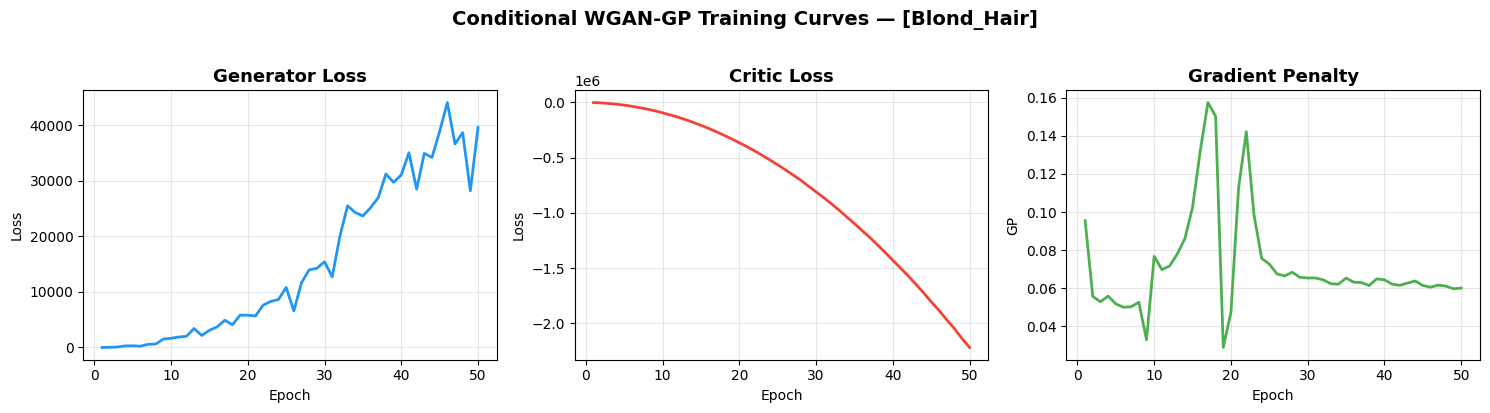

Saved: cwgan_gp_training1_curves.png


In [7]:
def plot_training_curves(history, attribute):
    epochs = range(1, len(history['epoch_G']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history['epoch_G'], color='#2196F3', linewidth=2)
    axes[0].set_title('Generator Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['epoch_C'], color='#F44336', linewidth=2)
    axes[1].set_title('Critic Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, history['epoch_GP'], color='#4CAF50', linewidth=2)
    axes[2].set_title('Gradient Penalty', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('GP')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'Conditional WGAN-GP Training Curves — [{attribute}]',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('cwgan_gp_training1_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cwgan_gp_training1_curves.png')


plot_training_curves(history, ATTRIBUTE)

## 8. Generate 50 Samples (Mixed Labels)

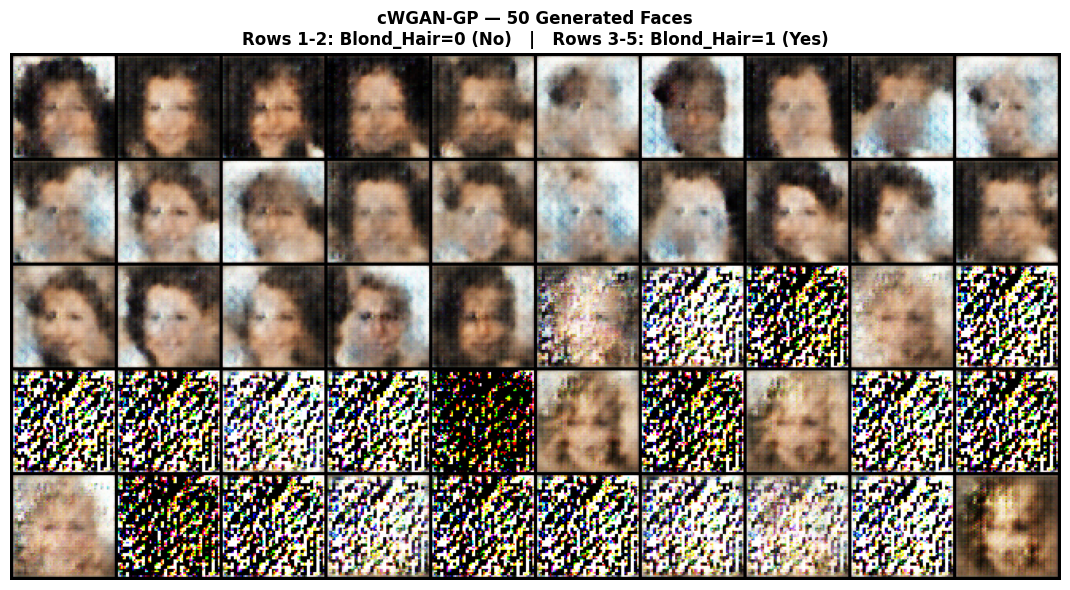

Saved: cwgan_gp_samples1_50.png


In [8]:
def generate_sample_grid(generator, latent_dim, n_samples=50, nrow=10, device=DEVICE):
    """
    Generate n_samples images with alternating labels (25 × label=0, 25 × label=1)
    and display them in a grid.
    """
    generator.eval()
    with torch.no_grad():
        z      = torch.randn(n_samples, latent_dim, device=device)
        # 25 negative, 25 positive
        labels = torch.tensor([0]*(n_samples//2) + [1]*(n_samples//2),
                               dtype=torch.long, device=device)
        images = generator(z, labels).cpu()

    grid = make_grid(images, nrow=nrow, normalize=True, value_range=(-1, 1), padding=2)
    plt.figure(figsize=(nrow * 1.2, (n_samples // nrow) * 1.2))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(f'cWGAN-GP — 50 Generated Faces\n'
              f'Rows 1-2: {ATTRIBUTE}=0 (No)   |   Rows 3-5: {ATTRIBUTE}=1 (Yes)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cwgan_gp_samples1_50.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cwgan_gp_samples1_50.png')
    generator.train()


generate_sample_grid(G, LATENT_DIM, n_samples=50, nrow=10)

## 9. Fixed-z Comparison

Keep the latent vector **z** fixed and only change the attribute label. If conditioning works, the same face identity should appear with and without the attribute.

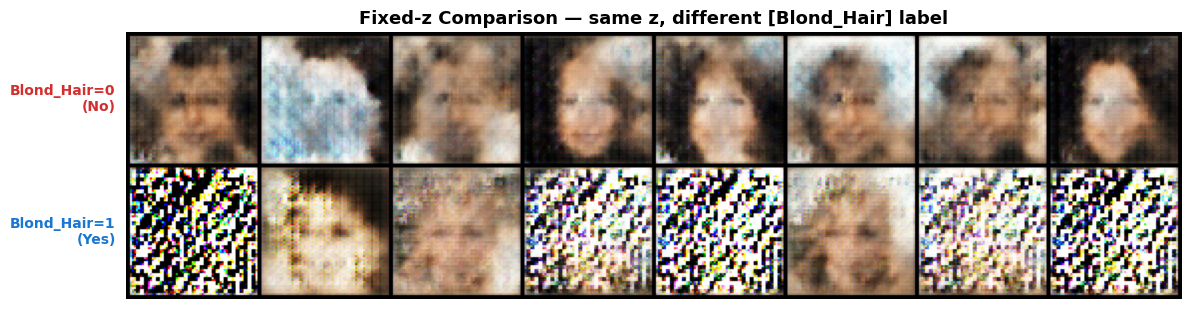

Saved: cwgan_gp_fixed_z.png


In [9]:
def fixed_z_comparison(generator, latent_dim, n_pairs=8, device=DEVICE):
    """
    For each of n_pairs fixed z vectors, generate two images:
      - label = 0  (attribute absent)
      - label = 1  (attribute present)

    Displayed as two rows:
      Row 1: all label=0 images
      Row 2: all label=1 images
    """
    generator.eval()
    with torch.no_grad():
        # Same n_pairs z vectors for both labels
        z       = torch.randn(n_pairs, latent_dim, device=device)
        labels0 = torch.zeros(n_pairs, dtype=torch.long, device=device)  # label=0
        labels1 = torch.ones( n_pairs, dtype=torch.long, device=device)  # label=1

        imgs0 = generator(z, labels0).cpu()   # (n_pairs, 3, 64, 64)
        imgs1 = generator(z, labels1).cpu()   # (n_pairs, 3, 64, 64)

    # Stack: row 1 = label=0, row 2 = label=1
    all_imgs = torch.cat([imgs0, imgs1], dim=0)   # (2*n_pairs, 3, 64, 64)
    grid = make_grid(all_imgs, nrow=n_pairs, normalize=True, value_range=(-1, 1), padding=2)

    fig, ax = plt.subplots(figsize=(n_pairs * 1.5, 3.5))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.axis('off')

    # Row labels on the left
    ax.text(-0.01, 0.75, f'{ATTRIBUTE}=0\n(No)', transform=ax.transAxes,
            fontsize=10, va='center', ha='right', color='#D32F2F', fontweight='bold')
    ax.text(-0.01, 0.25, f'{ATTRIBUTE}=1\n(Yes)', transform=ax.transAxes,
            fontsize=10, va='center', ha='right', color='#1976D2', fontweight='bold')

    plt.title(f'Fixed-z Comparison — same z, different [{ATTRIBUTE}] label',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cwgan_gp_fixed_z.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: cwgan_gp_fixed_z.png')
    generator.train()


fixed_z_comparison(G, LATENT_DIM, n_pairs=8)

## 10. Latent Interpolation (Fixed Label)

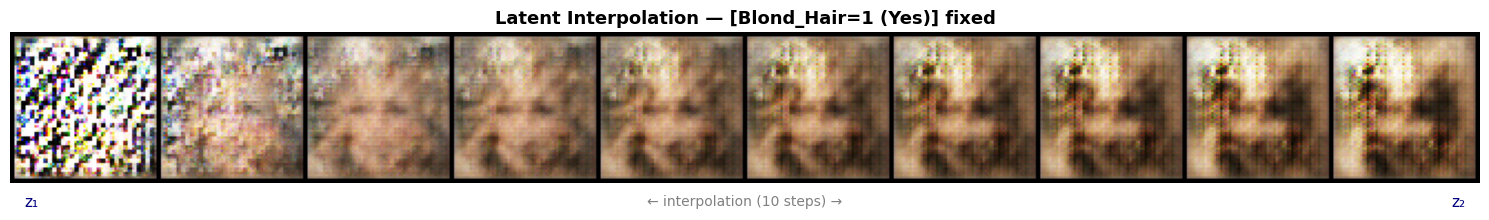

Saved: cwgan_gp_interp_label1.png


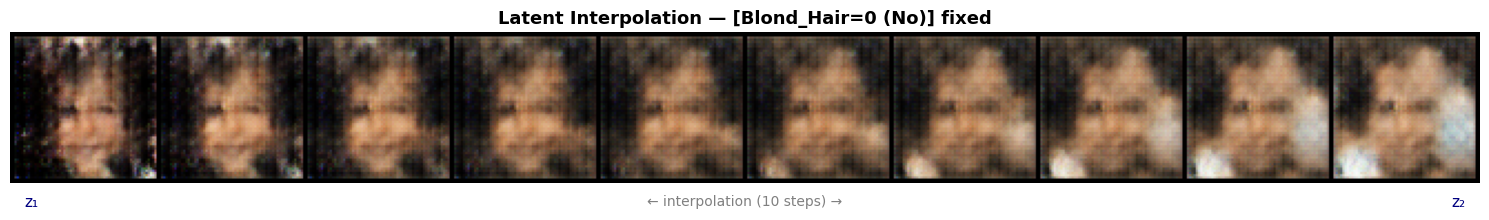

Saved: cwgan_gp_interp_label0.png


In [10]:
def latent_interpolation_conditional(generator, latent_dim,
                                     fixed_label=1, n_steps=10, device=DEVICE):
    """
    Linearly interpolate between z1 and z2 while keeping the condition
    label FIXED. This isolates changes due to latent space traversal
    from changes due to the condition.

    Args:
        fixed_label : 0 or 1 — condition to hold constant
        n_steps     : number of interpolation points (includes endpoints)
    """
    generator.eval()
    label_name = 'Yes' if fixed_label == 1 else 'No'

    with torch.no_grad():
        z1 = torch.randn(1, latent_dim, device=device)
        z2 = torch.randn(1, latent_dim, device=device)

        alphas   = torch.linspace(0, 1, n_steps, device=device)
        z_interp = (1 - alphas[:, None]) * z1 + alphas[:, None] * z2  # (n_steps, dim)

        # Same label for all interpolation steps
        labels = torch.full((n_steps,), fixed_label, dtype=torch.long, device=device)

        images = generator(z_interp, labels).cpu()

    grid = make_grid(images, nrow=n_steps, normalize=True, value_range=(-1, 1), padding=2)

    fig, ax = plt.subplots(figsize=(n_steps * 1.5, 2.2))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.axis('off')

    ax.text(0.01, -0.08, 'z₁', transform=ax.transAxes,
            fontsize=11, ha='left', va='top', color='navy')
    ax.text(0.5, -0.08, f'← interpolation ({n_steps} steps) →',
            transform=ax.transAxes, fontsize=10, ha='center', va='top', color='gray')
    ax.text(0.99, -0.08, 'z₂', transform=ax.transAxes,
            fontsize=11, ha='right', va='top', color='navy')

    plt.title(f'Latent Interpolation — [{ATTRIBUTE}={fixed_label} ({label_name})] fixed',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'cwgan_gp_interp_label{fixed_label}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    generator.train()


# Interpolate with label=1 (attribute present)
latent_interpolation_conditional(G, LATENT_DIM, fixed_label=1, n_steps=10)

# Interpolate with label=0 (attribute absent)
latent_interpolation_conditional(G, LATENT_DIM, fixed_label=0, n_steps=10)

## 11. Save Checkpoint

In [11]:
checkpoint = {
    'generator_state_dict' : G.state_dict(),
    'critic_state_dict'    : C.state_dict(),
    'opt_G_state_dict'     : opt_G.state_dict(),
    'opt_C_state_dict'     : opt_C.state_dict(),
    'history'              : history,
    'attribute'            : ATTRIBUTE,
    'hyperparams': {
        'LATENT_DIM': LATENT_DIM, 'EMBED_DIM': EMBED_DIM,
        'BATCH_SIZE': BATCH_SIZE, 'LR': LR, 'BETAS': BETAS,
        'N_CRITIC': N_CRITIC, 'LAMBDA_GP': LAMBDA_GP, 'NUM_EPOCHS': NUM_EPOCHS,
    },
}
torch.save(checkpoint, 'cwgan_gp_checkpoint1.pth')
print('Checkpoint saved: cwgan_gp_checkpoint1.pth')

Checkpoint saved: cwgan_gp_checkpoint1.pth


---
## 12. Report Section — Conditioning Analysis

### How Conditioning Is Implemented

#### Generator
The binary label `y` is passed through `nn.Embedding(2, 64)` to produce a 64-dimensional dense vector **e**. This is concatenated with the latent noise **z** to form a 192-dimensional input `[z ∥ e]`, which is then reshaped and fed into the first `ConvTranspose2d` layer. Because the label is injected at the very start of the network, condition information is present at every layer and every spatial location of the generated image.

#### Critic
The critic embeds the label via the same `nn.Embedding` then projects it to a full 64×64 spatial map using a linear layer. This map is concatenated channel-wise to the input image, giving a 4-channel input `(image_RGB, label_map)`. This design lets the critic check whether each local region of the image is consistent with the claimed label — a more expressive form of conditioning than injecting only at the bottleneck.

### Why Conditioning Works in cGANs

In an unconditional GAN, the generator maps **z → x** with no control over which mode of the data distribution it targets. A conditional GAN extends this to **z, y → x**, where **y** steers the generator toward a specific region of the data distribution (e.g. images where `Smiling=1`). The critic is trained simultaneously to distinguish real `(x, y)` pairs from fake `(G(z, y), y)` pairs, which forces the generator to produce images that are both realistic and consistent with the given label.

### Conditioning Reliability Analysis

To assess reliability:
- **Fixed-z comparison** (Section 9): Use the same z with label=0 and label=1. If conditioning is working, faces should remain similar in identity/pose while the attribute changes (e.g. mouth opens into a smile).
- **Latent interpolation with fixed label** (Section 10): Smooth transitions during interpolation with a constant label confirm the attribute is consistently applied across the latent space.

**Expected findings:**
- After sufficient training, the `label=1` column should visibly show more instances of the attribute than `label=0`.
- Early in training the condition may be weakly followed; it strengthens as the critic becomes better at penalising label-image mismatches.
- Imbalanced attributes (e.g. Eyeglasses are rare in CelebA) may lead to weaker conditioning on the minority class — a known limitation of cGANs without re-weighting.

### Summary Table

| Component | Conditioning Method |
|-----------|--------------------|
| Generator | Embedding → concat with z before first layer |
| Critic | Embedding → linear projection → spatial channel concat with image |
| Embedding dim | 64 |
| Loss | WGAN-GP (λ=10), critic trained 5× per G step |